In [ ]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil
import re
import warnings
warnings.filterwarnings('ignore')
import tifffile
from pathlib import Path
from scipy.spatial import cKDTree

import sys
sys.path.append('../..')

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import SR_Functions
SupRes_F = SR_Functions.SuperRes_Functions(camera="ximea")

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args   = {'sigma': 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = 'image'

In [3]:
# ── Acquisition parameters ─────────────────────────────────────────────────────
DATA_ROOT   = '/media/jbeckwith/Ezra Seagat/20260629_PFS_zStack/'
WORK_DIR    = '/media/jbeckwith/Ezra Seagat/20260629_PFS_zStack_Analysis/'
CAL_DIR     = '../../Camera_Calibrations/Ximea_Camera/'

N_Z_STEPS   = 21         # z-stage positions: -1000 to +1000 nm
N_REPEATS   = 100         # frames acquired at each z position
Z_STEP_NM   = 100        # step size in nm
Z_NM        = np.arange(-1000, 1100, Z_STEP_NM)  # shape (21,)

PIXEL_SIZE  = 69         # nm
NA          = 1.49
PFA         = 1e-4       # spot-detection false-positive rate
ROI_SIZE    = 40

# Excitation channels present in the data
CHANNELS = {
    '638': {
        'folder':       os.path.join(DATA_ROOT, 'PFS_zstack_638'),
        'peak_wl':      0.638,
        'glob_pattern': 'PFS_zstack_638_MMStack_Pos-*.ome.tif',
    },
    '561': {
        'folder':       os.path.join(DATA_ROOT, 'PFS_zstack_561'),
        'peak_wl':      0.561,
        'glob_pattern': 'PFS_zstack_561_MMStack_Pos-*.ome.tif',
    },

    '488': {
        'folder':       os.path.join(DATA_ROOT, 'PFS_zstack_488'),
        'peak_wl':      0.488,
        'glob_pattern': 'PFS_zstack_488_MMStack_Pos-*.ome.tif',
    },
}

# Minimum fraction of z-planes a spot must appear in to be analysed
MIN_PRESENCE_FRACTION = 0.5
MIN_PLANES = int(np.ceil(MIN_PRESENCE_FRACTION * N_Z_STEPS))

# Spatial matching tolerance for linking the same spot across z-planes (pixels)
MATCH_RADIUS_PX = 1.0

print(f'Z positions (nm): {Z_NM}')
print(f'Min planes for inclusion: {MIN_PLANES} / {N_Z_STEPS}')

os.makedirs(WORK_DIR, exist_ok=True)

Z positions (nm): [-1000  -900  -800  -700  -600  -500  -400  -300  -200  -100     0   100
   200   300   400   500   600   700   800   900  1000]
Min planes for inclusion: 11 / 21


In [ ]:
# ── Multi-file FOV handling ────────────────────────────────────────────────────
# MicroManager splits an OME-TIFF once a single stack would exceed its internal
# size limit (~4 GB). Each FOV here is N_Z_STEPS * N_REPEATS = 2100 frames,
# larger than that limit, so every FOV now spans two physical files: the main
# file, plus a continuation file with a numeric suffix before the extension:
#   PFS_zstack_638_..._MMStack_Pos-0-0.ome.tif      (first ~1857 frames)
#   PFS_zstack_638_..._MMStack_Pos-0-0_1.ome.tif    (remaining ~243 frames)
# The OME-XML that would normally let tifffile stitch these together is invalid
# for this acquisition ("invalid entry in coordinates array"), which is also why
# the rest of this notebook reads with is_ome=False. The helpers below stitch
# the physical files back into one logical FOV using page counts only (no OME
# metadata needed), so every downstream cell keeps treating "one FOV" as "one
# stack", and the exact frame split point never needs to be hardcoded.

_PART_RE = re.compile(r'^(?P<base>.+)_(?P<part>\d+)\.ome\.tif$')
_PAGE_COUNT_CACHE: dict[str, int] = {}


def build_fov_file_groups(folder, image_type='.ome.tif'):
    """Group a folder's split OME-TIFFs into one ordered file list per FOV.

    Returns {fov_base_name: [main_path, part1_path, part2_path, ...]}, sorted
    in frame order. FOVs with no continuation files get a single-element list.
    """
    all_files = sorted(f for f in os.listdir(folder) if f.endswith(image_type))
    parts_by_base = {}
    mains = []
    for f in all_files:
        m = _PART_RE.match(f)
        if m:
            parts_by_base.setdefault(m.group('base'), []).append((int(m.group('part')), f))
        else:
            mains.append(f)

    groups = {}
    for main in mains:
        base = main[: -len(image_type)]
        parts = [f for _, f in sorted(parts_by_base.get(base, []))]
        groups[base] = [os.path.join(folder, f) for f in [main] + parts]
    return groups


def _n_pages(path):
    key = str(Path(path).resolve())
    if key not in _PAGE_COUNT_CACHE:
        with tifffile.TiffFile(path, is_ome=False) as tf:
            _PAGE_COUNT_CACHE[key] = len(tf.pages)
    return _PAGE_COUNT_CACHE[key]


def fov_total_frames(file_group):
    """Total frame count across all physical files in a FOV group (metadata only)."""
    return sum(_n_pages(fp) for fp in file_group)


def read_full_fov_stack(file_group, dtype=None):
    """Read and concatenate every frame of a (possibly multi-file) FOV."""
    if len(file_group) == 1:
        with tifffile.TiffFile(file_group[0], is_ome=False) as tf:
            out = tf.asarray()
        return out.astype(dtype) if dtype else out

    counts = [_n_pages(fp) for fp in file_group]
    with tifffile.TiffFile(file_group[0], is_ome=False) as tf:
        shape = tf.pages[0].shape
    out = np.empty((sum(counts),) + shape, dtype=dtype or np.uint16)
    offset = 0
    for fp, n in zip(file_group, counts):
        with tifffile.TiffFile(fp, is_ome=False) as tf:
            out[offset:offset + n] = tf.asarray()
        offset += n
    return out


# Discover FOV groups for every channel up front
FOV_GROUPS = {ch_name: build_fov_file_groups(ch_info['folder'])
              for ch_name, ch_info in CHANNELS.items()}

for ch_name, groups in FOV_GROUPS.items():
    n_split = sum(1 for g in groups.values() if len(g) > 1)
    print(f'[{ch_name}] {len(groups)} FOV(s), {n_split} split across multiple files')
    for base, paths in sorted(groups.items()):
        if len(paths) > 1:
            print(f'    {base}: {len(paths)} files -> {[os.path.basename(p) for p in paths]}')

In [4]:
# ── Camera calibration ─────────────────────────────────────────────────────────
gain     = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset   = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))
readnoise = IO.read_tiff(os.path.join(CAL_DIR, 'readnoise.tif'))
rqe      = IO.read_tiff(os.path.join(CAL_DIR, 'rqe.tif'))

print(f'Calibration maps loaded — chip shape: {gain.shape}')

Calibration maps loaded — chip shape: (1544, 2064)


In [ ]:
# ── Inspect one stack — verify frame ordering ──────────────────────────────────
# Frame ordering (MicroManager SlicesFirst=True):
#   page_index = z_stage_idx * N_REPEATS + repeat_idx
#   z_stage_idx = 0..20 → z_nm = -1000..+1000 nm
#   repeat_idx  = 0..(N_REPEATS-1)
# Each FOV may span multiple physical files (see FOV_GROUPS above); frames are
# concatenated in file order before reshaping.

example_base  = sorted(FOV_GROUPS['638'].keys())[0]
example_group = FOV_GROUPS['638'][example_base]
print(f'Example FOV: {example_base}  ({len(example_group)} file(s))')

stack = read_full_fov_stack(example_group)   # (N_Z*N_REPEATS, H, W)

print(f'Stack shape: {stack.shape}  dtype: {stack.dtype}')
assert stack.shape[0] == N_Z_STEPS * N_REPEATS, (
    f'Expected {N_Z_STEPS * N_REPEATS} frames, got {stack.shape[0]}')

# Mean signal per z-step — sanity check that the stack is correctly ordered
stack_4d = stack.reshape(N_Z_STEPS, N_REPEATS, stack.shape[1], stack.shape[2])
mean_per_z = stack_4d.mean(axis=(1, 2, 3))
del stack, stack_4d

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(Z_NM, mean_per_z, 'o-', ms=4)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Nominal z / nm')
ax.set_ylabel('Mean signal (ADU)')
ax.set_title(f'Signal vs z — {example_base}')
plt.tight_layout()
plt.show()

In [ ]:
# ── Spot detection preview — tune parameters before running the full fit ───────
# Detection is performed on the sum of ALL N_Z_STEPS*N_REPEATS frames (same as
# fit_QD_data). Each panel shows the summed image for one z-step (N_REPEATS
# repeats) with detected spot positions overlaid. Adjust parameters below and
# re-run until satisfied.

PFA_PREVIEW           = PFA    # lower → fewer but more confident spots
SIGMA_PREVIEW         = 1.5    # Gaussian detection sigma (pixels)
FRACTION_TRUE_PREVIEW = 0.5    # prior on fraction of pixels containing true spots

GRID_ROWS, GRID_COLS = 5, 5   # 25 slots for 21 z-steps; last 4 left blank

for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    groups = FOV_GROUPS[ch_name]
    if not groups:
        print(f'[{ch_name}] No .ome.tif files found, skipping')
        continue

    example_base  = sorted(groups.keys())[0]
    example_group = groups[example_base]
    print(f'[{ch_name}] Loading {example_base} ({len(example_group)} file(s))...')

    full = read_full_fov_stack(example_group, dtype=np.float32)   # (N_Z*N_REPEATS, H, W)
    full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])

    # Calibration crops (mirrors what fit_QD_data does internally)
    start_x, start_y, width, height = SupRes_F.helper.load_metadata_roi(
        ch_folder, SupRes_F.io, use_fallback=True)
    if width is None:
        height, width = full.shape[1], full.shape[2]
        start_x = start_y = 0

    cropped = SupRes_F.helper.crop_calibration_maps(
        {'gain_map': gain, 'offset_map': offset, 'read_noise': readnoise,
         'rqe': rqe, 'variance': variance},
        start_x, start_y, width, height)
    g_c   = cropped['gain_map']
    o_c   = cropped['offset_map']
    var_c = cropped['variance']

    # Detect on the sum of ALL frames (exactly as fit_QD_data will)
    n_total  = N_Z_STEPS * N_REPEATS
    var_sum  = var_c * n_total
    off_sum  = o_c  * n_total
    summed   = full.sum(axis=0)   # (H, W)

    img_detect = SupRes_F._demosaic_image(
        summed, use_variance_aware=True,
        gain_map=g_c, offset_map=off_sum, variance=var_sum)

    detected = SupRes_F.spot_detection.detect_puncta_in_image(
        img_detect,
        pfa=PFA_PREVIEW,
        variance=var_sum,
        wavelength=ch_info['peak_wl'],
        pixel_size=SupRes_F.pixel_size,
        NA=NA,
        sigma=SIGMA_PREVIEW,
        fraction_true=FRACTION_TRUE_PREVIEW,
    )
    n_spots = len(detected)
    print(f'  {n_spots} spots detected')

    # 5×5 grid: one panel per z-step, unused slots hidden
    fig, axs = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(18, 18))
    axs_flat = axs.ravel()

    for zi in range(GRID_ROWS * GRID_COLS):
        ax = axs_flat[zi]
        if zi >= N_Z_STEPS:
            ax.axis('off')
            continue
        img = full_4d[zi].sum(axis=0).astype(float)
        vmin, vmax = np.percentile(img, [0.1, 99.9])
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax,
                  origin='upper', interpolation='nearest')
        if n_spots > 0:
            ax.scatter(detected[:, 1], detected[:, 0],
                       s=12, marker='+', color='lime', linewidths=0.8, alpha=0.9)
        ax.set_title(f'z = {Z_NM[zi]:+.0f} nm', fontsize=9)
        ax.axis('off')

    plt.suptitle(
        f'{ch_name} nm — {example_base}\n'
        f'{n_spots} spots  (pfa={PFA_PREVIEW:.0e}, σ={SIGMA_PREVIEW})',
        fontsize=11, y=1.01)
    plt.tight_layout(pad=0.5)
    plt.show()

    del full, full_4d, summed, img_detect, detected

In [ ]:
# ── Detect spots & fit every frame per molecule ───────────────────────────────
# Strategy:
#   1. Sum ALL N_Z_STEPS*N_REPEATS frames → detect spots once per FOV.
#      In-focus frames dominate the sum; defocused frames add only diffuse background.
#   2. fit_QD_data fits every frame at every detected spot location.
#   3. Results: {FOV}.h5 alongside the FOV's main .ome.tif, with columns:
#        puncta_id, frame, xc, yc, A_B, A_G, A_R, photons, ...
#   Z-centering is done per molecule in a later cell.
#
# Multi-file FOVs: fit_QD_data (SR_Functions.py) assumes one physical file per
# FOV. Each FOV here is split across a main file and a continuation file (see
# FOV_GROUPS above), so three of its collaborators are monkeypatched for the
# duration of this cell, scoped to SupRes_F's own io/helper instances only
# (the notebook's separate top-level `IO` instance from cell 0 is untouched):
#   - helper.file_search      → drop continuation files from the per-channel
#                               FOV list so each FOV is only visited once
#   - io.get_num_pages_in_TIF → report the combined frame count across a FOV's
#                               files
#   - io.read_tiff            → translate a global frame index/list into the
#                               right physical file(s) and stitch the result
#                               back together
# This reuses fit_QD_data's detection / chunked-fitting / save logic unchanged.
# The patches are left in place afterwards; they no-op (fall back to the
# original methods) for any path that isn't one of this dataset's FOV files.

# Relax the PSF-width filter: the default _filter_fit_results rejects s_x/s_y >= 3 px,
# which discards defocused PSFs at extreme z. For this z-scan analysis we only require
# positive sigma; the upper bound is removed.
import types

def _relaxed_filter_fit_results(self, fit_results, width, height):
    mask = (
        fit_results.notna().all(axis=1)
        & (fit_results["xc"] > 0) & (fit_results["xc"] < width)
        & (fit_results["yc"] > 0) & (fit_results["yc"] < height)
        & (fit_results["s_x"] > 0)   # no upper bound — PSF grows with defocus
        & (fit_results["s_y"] > 0)
        & (fit_results["A_B"] > 0) & (fit_results["A_G"] > 0) & (fit_results["A_R"] > 0)
        & (fit_results["bg_B"] > 0) & (fit_results["bg_G"] > 0) & (fit_results["bg_R"] > 0)
    )
    return fit_results[mask].reset_index(drop=True)

SupRes_F._filter_fit_results = types.MethodType(_relaxed_filter_fit_results, SupRes_F)
print('Relaxed sigma filter applied (no upper PSF-width bound).')

_orig_file_search   = type(SupRes_F.helper).file_search
_orig_get_num_pages = type(SupRes_F.io).get_num_pages_in_TIF
_orig_read_tiff     = type(SupRes_F.io).read_tiff


def _make_multipart_patches(file_groups):
    """file_groups: {resolved main-file path: [main_path, part1_path, ...]}"""

    def _patched_file_search(self, folder, string1, string2):
        files = _orig_file_search(self, folder, string1, string2)
        if string1 == '.ome.tif':
            files = [f for f in files if not _PART_RE.match(os.path.basename(f))]
        return files

    def _patched_get_num_pages(self, filename):
        group = file_groups.get(str(Path(filename).resolve()))
        if group is None:
            return _orig_get_num_pages(self, filename)
        return fov_total_frames(group)

    def _patched_read_tiff(self, file_path, frame=None, dtype='float32', memmap=True):
        group = file_groups.get(str(Path(file_path).resolve()))
        if group is None:
            return _orig_read_tiff(self, file_path, frame=frame, dtype=dtype, memmap=memmap)

        counts = [_n_pages(fp) for fp in group]
        bounds = np.cumsum([0] + counts)

        if frame is None:
            return np.concatenate(
                [_orig_read_tiff(self, fp, frame=None, dtype=dtype, memmap=memmap)
                 for fp in group], axis=0)

        single = not hasattr(frame, '__len__')
        frame_arr = np.asarray([frame] if single else frame)

        out = None
        for fp, lo, hi in zip(group, bounds[:-1], bounds[1:]):
            sel = (frame_arr >= lo) & (frame_arr < hi)
            if not sel.any():
                continue
            local = (frame_arr[sel] - lo).tolist()
            data = _orig_read_tiff(self, fp, frame=local if len(local) > 1 else local[0],
                                    dtype=dtype, memmap=memmap)
            if data.ndim == 2:
                data = data[np.newaxis]
            if out is None:
                out = np.empty((len(frame_arr),) + data.shape[1:], dtype=data.dtype)
            out[np.where(sel)[0]] = data

        return out[0] if single else out

    return _patched_file_search, _patched_get_num_pages, _patched_read_tiff


for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    groups = FOV_GROUPS[ch_name]
    if not groups:
        print(f'[{ch_name}] No FOVs found, skipping')
        continue

    h5_count = sum(1 for f in os.listdir(ch_folder) if f.endswith('.h5'))
    if h5_count >= len(groups):
        print(f'[{ch_name}] All {len(groups)} FOV(s) already fitted, skipping')
        print(f'  NOTE: delete the .h5 files and re-run if the filter was previously strict')
        continue

    file_groups_by_main = {
        str(Path(paths[0]).resolve()): paths for paths in groups.values()
    }
    _fs, _gp, _rt = _make_multipart_patches(file_groups_by_main)
    SupRes_F.helper.file_search      = types.MethodType(_fs, SupRes_F.helper)
    SupRes_F.io.get_num_pages_in_TIF = types.MethodType(_gp, SupRes_F.io)
    SupRes_F.io.read_tiff            = types.MethodType(_rt, SupRes_F.io)

    print(f'[{ch_name}] Fitting {len(groups)} FOV(s) — this will take a while...')
    SupRes_F.fit_QD_data(
        image_folder=ch_folder,
        smoothing_function=smoothing_function,
        gain_map=gain,
        offset_map=offset,
        rqe=rqe,
        read_noise=readnoise,
        variance=variance,
        n_frames_sum=N_Z_STEPS * N_REPEATS,   # sum ALL frames for detection
        pfa=PFA,
        ROI_size=ROI_SIZE,
        peak_wavelength=ch_info['peak_wl'],
        NA=NA,
        image_type='.ome.tif',
    )
    print(f'  [{ch_name}] Done.')

print('All fitting complete.')

In [ ]:
# ── Load fitting results and decode frame → z_step_idx / repeat_idx ──────────
# fit_QD_data stores absolute frame numbers (0..524).
# Encoding: frame = z_step_idx * N_REPEATS + repeat_idx
#
# puncta_id is only unique within a single FOV. A globally unique mol_uid is
# created here so that downstream groupby operations across multiple FOVs
# do not conflate molecules from different fields of view.

all_results = {}

for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    h5_files  = sorted(f for f in os.listdir(ch_folder) if f.endswith('.h5'))
    if not h5_files:
        print(f'[{ch_name}] No H5 files found')
        continue

    all_results[ch_name] = {}
    for h5_name in h5_files:
        fov_name = h5_name.replace('.h5', '')
        h5_path  = os.path.join(ch_folder, h5_name)
        try:
            df = pd.read_hdf(h5_path)
        except Exception as e:
            print(f'  Warning: failed to load {h5_path}: {e}')
            continue

        df['z_step_idx'] = (df['frame'] // N_REPEATS).astype(int).clip(0, N_Z_STEPS - 1)
        df['repeat_idx'] = (df['frame']  % N_REPEATS).astype(int)
        df['z_nm']       = Z_NM[df['z_step_idx'].values]
        # Globally unique molecule identifier across all FOVs and channels
        df['mol_uid']    = ch_name + '_' + fov_name + '_' + df['puncta_id'].astype(str)

        all_results[ch_name][fov_name] = df
        n_mol = df['mol_uid'].nunique()
        print(f'  [{ch_name}] {fov_name}: {len(df):,} fits, {n_mol} molecules, '
              f'{df["z_step_idx"].nunique()} z-steps')

print('Load complete.')

In [ ]:
plt.hist(np.log10(df['photons']),100);
plt.show()

In [46]:
# ── Filter molecules by minimum z-plane presence ──────────────────────────────
# Keep only molecules successfully fitted in at least MIN_PLANES distinct z-steps.

matched_results = {}

for ch_name, fov_dict in all_results.items():
    matched_results[ch_name] = {}
    for fov_name, df in fov_dict.items():
        plane_count = df.groupby("mol_uid")["z_step_idx"].nunique()
        good_ids    = plane_count[plane_count >= MIN_PLANES].index
        df_good     = df[df["mol_uid"].isin(good_ids)].copy()

        matched_results[ch_name][fov_name] = df_good
        print(f"  [{ch_name}] {fov_name}: {len(good_ids)} / {df['mol_uid'].nunique()} "
              f"molecules present in ≥{MIN_PLANES}/{N_Z_STEPS} z-steps")

print("Filtering complete.")

  [638] PFS_zstack_638_MMStack_Pos-0-0: 252 fits dropped (photons < 1000), 14 / 14 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-0-1: 1171 fits dropped (photons < 1000), 19 / 19 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-0-2: 220 fits dropped (photons < 1000), 14 / 14 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-0-3: 138 fits dropped (photons < 1000), 13 / 13 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-0-4: 1133 fits dropped (photons < 1000), 23 / 23 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-1-0: 120 fits dropped (photons < 1000), 7 / 7 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-1-1: 30 fits dropped (photons < 1000), 8 / 8 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-1-2: 283 fits dropped (photons < 1000), 14 / 14 molecules kept (≥11/21 z-steps)
  [638] PFS_zstack_638_MMStack_Pos-1-3: 585 fits dropped (photons < 1000), 17 / 17 

In [47]:
# ── Z-centering: global focus z-step ──────────────────────────────────────────
# With the PFS active and beads on the coverslip, all molecules share the same
# focal plane.  Per-molecule centering on 21 noisy sigma estimates introduces
# more error than it corrects.  Instead, find the single z-step with minimum
# mean PSF width across all molecules and channels, then use that as z=0
# for every localisation.

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE

# Pool all channels/FOVs to find the global focus step
all_data = pd.concat(
    [df for fov_dict in matched_results.values() for df in fov_dict.values()],
    ignore_index=True,
)
all_data['sigma_mean'] = (all_data['s_x'] + all_data['s_y']) / 2.0
global_mean_sigma = all_data.groupby('z_step_idx')['sigma_mean'].mean()
global_focus_idx  = int(global_mean_sigma.idxmin())
global_focus_nm   = float(Z_NM[global_focus_idx])

print(f'Global focus: z_step_idx = {global_focus_idx}  '
      f'(z = {global_focus_nm:+.0f} nm nominal)')
print(f'  Mean FWHM at focus: '
      f'{global_mean_sigma[global_focus_idx] * FWHM_FACTOR:.1f} nm')

# Apply the same z=0 to every molecule
centered_results = {}
for ch_name, fov_dict in matched_results.items():
    centered_results[ch_name] = {}
    for fov_name, df in fov_dict.items():
        df = df.copy()
        df['z_rel_nm'] = df['z_nm'] - global_focus_nm
        centered_results[ch_name][fov_name] = df

print('Z-centering complete (global criterion: minimum mean PSF width).')

Global focus: z_step_idx = 17  (z = +700 nm nominal)
  Mean FWHM at focus: 663.4 nm
Z-centering complete (global criterion: minimum mean PSF width).


In [48]:
# ── Z-centering per molecule ───────────────────────────────────────────────────
# For each molecule (mol_uid) find the z-step where mean photons is maximum →
# that is the individual in-focus position (z_rel = 0).
# Adds 'z_rel_nm' = z_nm − z_peak_nm, independently per molecule.

centered_results = {}

for ch_name, fov_dict in matched_results.items():
    centered_results[ch_name] = {}
    for fov_name, df in fov_dict.items():
        mean_ph = (
            df.groupby(['mol_uid', 'z_step_idx'])['s_x']
            .mean()
            .reset_index()
        )
        peak_z_idx = (
            mean_ph.loc[mean_ph.groupby('mol_uid')['s_x'].idxmin()]
            .set_index('mol_uid')['z_step_idx']
        )
        df = df.copy()
        df['z_peak_nm'] = Z_NM[df['mol_uid'].map(peak_z_idx).fillna(10).astype(int)]
        df['z_rel_nm']  = df['z_nm'] - df['z_peak_nm']
        centered_results[ch_name][fov_name] = df

print('Z-centering complete.')

Z-centering complete.


In [49]:
# ── Precision vs z ─────────────────────────────────────────────────────────────
# σ_xy: for each z-bin, compute the per-molecule mean XY position across its 25
# repeats, then take the RMS of the residuals (actual − mean) and convert to nm.
# This is the localisation precision: how consistently we can place the same
# molecule at the same z-step across repeated exposures.
# Formula: σ_xy = sqrt((std(Δx)² + std(Δy)²) / 2) × pixel_size_nm
#
# σ_col: std of the Euclidean distance of each (A_R, A_G, A_B) vector from its
# per-molecule mean, pooled across all molecules in the z-bin.
#
# A_B, A_G, A_R are already normalised fractions (sum = 1) from write_h5_database.
# mol_uid ensures molecules from different FOVs are never conflated.

colour_cols = [c for c in ['A_R', 'A_G', 'A_B'] if c in next(
    iter(next(iter(centered_results.values())).values())
).columns]
print(f'Colour columns: {colour_cols}  (normalised fractions, sum = 1)')

def precision_per_zbin(df, z_bins, pixel_size_nm=PIXEL_SIZE):
    rows = []
    df = df.copy()
    df['z_bin'] = pd.cut(df['z_rel_nm'], bins=z_bins, labels=False)
    bin_centres = 0.5 * (z_bins[:-1] + z_bins[1:])

    for b_idx, g in df.groupby('z_bin', observed=True):
        if len(g) < 5:
            continue
        # Residuals from per-molecule mean position within this z-bin
        mol_mean_x = g.groupby('mol_uid')['xc'].transform('mean')
        mol_mean_y = g.groupby('mol_uid')['yc'].transform('mean')
        ex = g['xc'] - mol_mean_x
        ey = g['yc'] - mol_mean_y
        sigma_xy = np.sqrt((np.nanstd(ex)**2 + np.nanstd(ey)**2) / 2) * pixel_size_nm

        sigma_col = np.nan
        if len(colour_cols) >= 2:
            col_arr  = g[colour_cols].values.astype(float)
            mean_col = col_arr.mean(axis=0, keepdims=True)
            sigma_col = np.nanstd(np.linalg.norm(col_arr - mean_col, axis=1))

        rows.append({
            'z_rel_nm':     float(bin_centres[int(b_idx)]),
            'sigma_xy_nm':  sigma_xy,
            'sigma_colour': sigma_col,
            'n_locs':       len(g),
        })
    return pd.DataFrame(rows)

Z_BINS = np.arange(-1050, 1150, Z_STEP_NM)

precision_by_ch = {}
for ch_name, fov_dict in centered_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    prec   = precision_per_zbin(all_ch, Z_BINS)
    precision_by_ch[ch_name] = prec
    print(f'\n[{ch_name}]')
    print(prec.to_string(index=False))

Colour columns: ['A_R', 'A_G', 'A_B']  (normalised fractions, sum = 1)

[638]
 z_rel_nm  sigma_xy_nm  sigma_colour  n_locs
  -1000.0    37.633503      0.096306    7470
   -900.0    36.211029      0.090876    7694
   -800.0    37.107382      0.088243    7767
   -700.0    36.409089      0.079599    7951
   -600.0    36.708322      0.075567    8110
   -500.0    37.139732      0.071163    8185
   -400.0    37.946451      0.065286    8378
   -300.0    37.302876      0.066625    8470
   -200.0    39.415562      0.060797    8675
   -100.0    41.202730      0.059371    8708
      0.0    35.447464      0.062580    8849
    100.0    39.423225      0.060278    8526
    200.0    37.680983      0.067338    8223
    300.0    39.149248      0.060042    7134
    400.0    46.505981      0.014913    4530
    500.0    54.228442      0.060864    2881
    600.0    56.952261      0.086055    2428
    700.0    59.632415      0.105658    1980
    800.0    63.459239      0.105942    1634
    900.0    63.603444

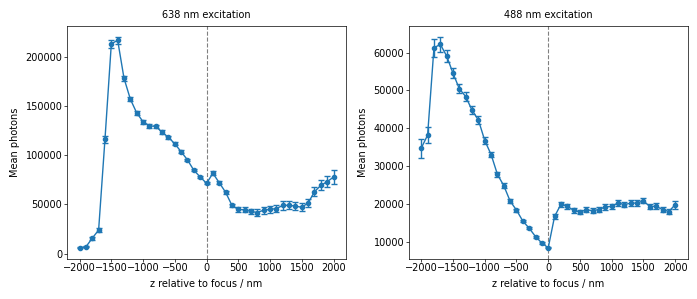

In [50]:
# ── Total photons vs z (sanity check — should peak at z=0) ────────────────────
fs = plotter.config.font_size
n_ch = len(centered_results)
fig, axs = plt.subplots(1, n_ch, figsize=(3.5 * n_ch, 3.0), squeeze=False)

for ax, (ch_name, fov_dict) in zip(axs[0], centered_results.items()):
    all_ch  = pd.concat(list(fov_dict.values()), ignore_index=True)
    mean_ph = all_ch.groupby('z_rel_nm')['photons'].mean()
    sem_ph  = all_ch.groupby('z_rel_nm')['photons'].sem()
    ax.errorbar(mean_ph.index, mean_ph.values, yerr=sem_ph.values,
                fmt='o-', ms=3, lw=1.0, capsize=2)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('z relative to focus / nm', fontsize=fs)
    ax.set_ylabel('Mean photons', fontsize=fs)
    ax.set_title(f'{ch_name} nm excitation', fontsize=fs)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'photons_vs_z.svg'), dpi=300, format='svg')
plt.show()

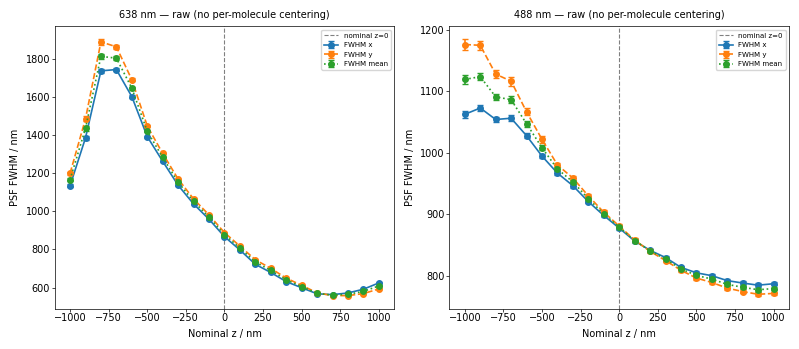


[638] mean FWHM (nm) per z-step:
 z_nm        mean  count
-1000 1167.746338   6901
 -900 1436.958374   7272
 -800 1815.330200   7948
 -700 1805.738281   8295
 -600 1648.147095   8528
 -500 1421.555298   8668
 -400 1284.262451   8726
 -300 1153.907593   8768
 -200 1052.720093   8890
 -100  970.300659   8960
    0  878.259155   9043
  100  807.926514   8966
  200  734.174133   8911
  300  690.106262   8941
  400  640.359619   8969
  500  605.383118   8947
  600  569.677490   8855
  700  560.242737   8924
  800  564.465027   8870
  900  579.706055   8846
 1000  608.432922   8838

[488] mean FWHM (nm) per z-step:
 z_nm        mean  count
-1000 1119.277832   6418
 -900 1123.790527   6732
 -800 1090.997681   6858
 -700 1086.285767   6986
 -600 1047.089111   7016
 -500 1008.185974   7096
 -400  973.554382   7214
 -300  952.634644   7204
 -200  925.222168   7263
 -100  900.616516   7404
    0  879.152466   7444
  100  857.231018   7495
  200  840.472473   7470
  300  827.093384   7538
  400  

In [51]:
# ── Diagnostic: raw PSF FWHM vs absolute z-step (no centering) ────────────────
# Before trusting the per-molecule z-centering, verify the raw data is sensible.
# Average s_x and s_y over ALL molecules at each z_step_idx and plot as FWHM.
# A well-behaved dataset should show a clear minimum at the in-focus z-step
# regardless of any per-molecule z-centering.

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE

n_ch = len(matched_results)
fig, axs = plt.subplots(1, n_ch, figsize=(4.0 * n_ch, 3.5), squeeze=False)
fs = plotter.config.font_size

for ax, (ch_name, fov_dict) in zip(axs[0], matched_results.items()):
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    all_ch['fwhm_x']    = all_ch['s_x'] * FWHM_FACTOR
    all_ch['fwhm_y']    = all_ch['s_y'] * FWHM_FACTOR
    all_ch['fwhm_mean'] = (all_ch['fwhm_x'] + all_ch['fwhm_y']) / 2.0

    grp = all_ch.groupby('z_step_idx')
    for col, label, ls in [('fwhm_x',    'FWHM x',    '-'),
                            ('fwhm_y',    'FWHM y',    '--'),
                            ('fwhm_mean', 'FWHM mean', ':')]:
        m = grp[col].mean()
        s = grp[col].sem()
        ax.errorbar(Z_NM[m.index], m.values, yerr=s.values,
                    fmt='o' + ls, ms=4, lw=1.2, capsize=2, label=label)

    ax.axvline(0, color='gray', lw=0.8, ls='--', label='nominal z=0')
    ax.set_xlabel('Nominal z / nm', fontsize=fs)
    ax.set_ylabel('PSF FWHM / nm', fontsize=fs)
    ax.set_title(f'{ch_name} nm — raw (no per-molecule centering)', fontsize=fs)
    ax.legend(fontsize=fs - 2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'psf_fwhm_vs_z_raw.svg'), dpi=300, format='svg')
plt.show()

# Also print the raw mean FWHM at each z-step for quick inspection
for ch_name, fov_dict in matched_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    all_ch['fwhm_mean'] = (all_ch['s_x'] + all_ch['s_y']) / 2.0 * FWHM_FACTOR
    summary = all_ch.groupby('z_step_idx')['fwhm_mean'].agg(['mean','count']).reset_index()
    summary['z_nm'] = Z_NM[summary['z_step_idx'].values]
    print(f'\n[{ch_name}] mean FWHM (nm) per z-step:')
    print(summary[['z_nm','mean','count']].to_string(index=False))

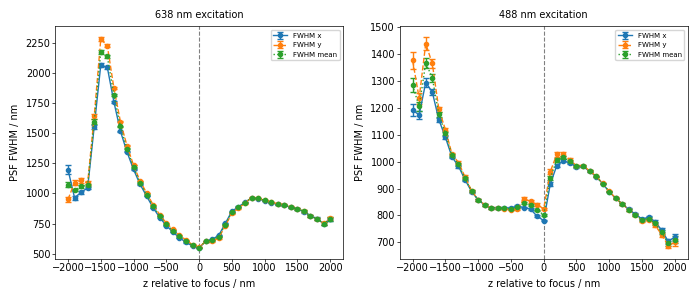

In [52]:
# ── PSF FWHM vs z ──────────────────────────────────────────────────────────────
# s_x, s_y are Gaussian σ in pixels.  FWHM = 2√(2 ln 2) × σ × pixel_size_nm.
# Should be minimum at z_rel = 0 (this is the centering criterion).

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE   # px → nm conversion

n_ch = len(centered_results)
fig, axs = plt.subplots(1, n_ch, figsize=(3.5 * n_ch, 3.0), squeeze=False)
fs = plotter.config.font_size

for ax, (ch_name, fov_dict) in zip(axs[0], centered_results.items()):
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)

    # Mean FWHM per z-bin (100 nm = one z-step)
    all_ch['fwhm_x'] = all_ch['s_x'] * FWHM_FACTOR
    all_ch['fwhm_y'] = all_ch['s_y'] * FWHM_FACTOR
    all_ch['fwhm_mean'] = (all_ch['fwhm_x'] + all_ch['fwhm_y']) / 2.0

    grp = all_ch.groupby('z_rel_nm')
    for col, label, ls in [('fwhm_x', 'FWHM x', '-'),
                            ('fwhm_y', 'FWHM y', '--'),
                            ('fwhm_mean', 'FWHM mean', ':')]:
        m = grp[col].mean()
        s = grp[col].sem()
        ax.errorbar(m.index, m.values, yerr=s.values,
                    fmt='o' + ls, ms=3, lw=1.0, capsize=2, label=label)

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('z relative to focus / nm', fontsize=fs)
    ax.set_ylabel('PSF FWHM / nm', fontsize=fs)
    ax.set_title(f'{ch_name} nm excitation', fontsize=fs)
    ax.legend(fontsize=fs - 2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'psf_fwhm_vs_z.svg'), dpi=300, format='svg')
plt.show()

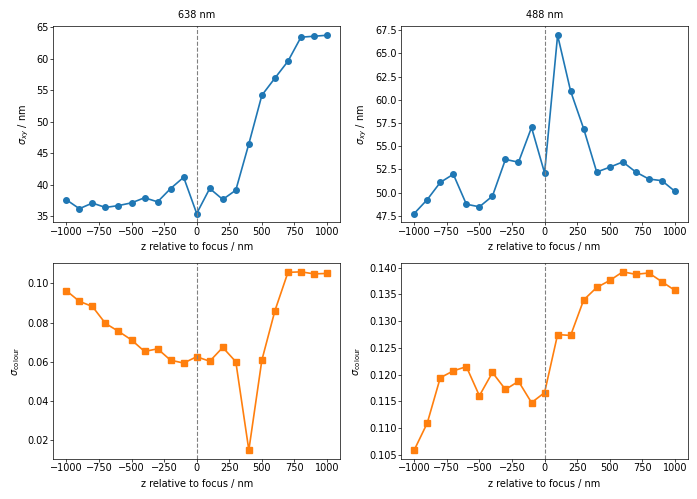

In [53]:
# ── Localisation and colour precision vs z ────────────────────────────────────
fig, axs = plt.subplots(2, n_ch, figsize=(3.5 * n_ch, 5.0), squeeze=False)

for col_idx, (ch_name, prec) in enumerate(precision_by_ch.items()):
    ax_xy  = axs[0, col_idx]
    ax_col = axs[1, col_idx]

    # σ_xy
    ax_xy.plot(prec['z_rel_nm'], prec['sigma_xy_nm'], 'o-', ms=4, lw=1.2)
    ax_xy.axvline(0, color='gray', lw=0.8, ls='--')
    ax_xy.set_xlabel('z relative to focus / nm', fontsize=fs)
    ax_xy.set_ylabel(r'$\sigma_{xy}$ / nm', fontsize=fs)
    ax_xy.set_title(f'{ch_name} nm', fontsize=fs)

    # σ_colour
    if prec['sigma_colour'].notna().any():
        ax_col.plot(prec['z_rel_nm'], prec['sigma_colour'], 's-', ms=4, lw=1.2, color='C1')
        ax_col.axvline(0, color='gray', lw=0.8, ls='--')
        ax_col.set_xlabel('z relative to focus / nm', fontsize=fs)
        ax_col.set_ylabel(r'$\sigma_{\rm colour}$', fontsize=fs)
    else:
        ax_col.text(0.5, 0.5, 'No colour data', ha='center', va='center',
                    transform=ax_col.transAxes, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'precision_vs_z.svg'), dpi=300, format='svg')
plt.show()

In [ ]:
# ── Example PSF images at several z-steps (summed over N_REPEATS repeats) ─────
show_z_idxs = [0, 5, 10, 15, 20]
ch_show  = '638'
example_base  = sorted(FOV_GROUPS[ch_show].keys())[0]
example_group = FOV_GROUPS[ch_show][example_base]

full = read_full_fov_stack(example_group)   # (N_Z*N_REPEATS, H, W)
full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])

fig, axs = plt.subplots(1, len(show_z_idxs),
                         figsize=(2.0 * len(show_z_idxs), 2.2), squeeze=True)
for ax, i in zip(axs, show_z_idxs):
    img = full_4d[i].sum(axis=0).astype(float)
    vmin, vmax = np.percentile(img, [0.5, 99.5])
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='upper',
              interpolation='nearest')
    ax.set_title(f'z={Z_NM[i]:+.0f} nm', fontsize=7)
    ax.axis('off')

plt.suptitle(f'{ch_show} nm — {example_base} (summed {N_REPEATS} frames)', fontsize=8)
plt.tight_layout()
plt.show()
del full, full_4d

In [ ]:
# ── Example detections across z-planes (fitted positions on summed images) ─────
# For each shown z-step: sum the N_REPEATS repeats → background image,
# then overlay the fitted (xc, yc) positions of all molecules at that z-step.
# Uses centered_results so z_rel_nm is available.

show_z_rel = [-1000, -500, 0, 500, 1000]  # nm relative to each molecule's focus

ch_show    = '638'
fov_show   = sorted(centered_results.get(ch_show, {}).keys())[0]
df_show    = centered_results[ch_show][fov_show]

# Load the original (possibly multi-file) stack for this FOV
example_group = FOV_GROUPS[ch_show][fov_show]
full = read_full_fov_stack(example_group)
full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])
del full

# Match z_rel targets to actual z_step indices (use z_nm - per-FOV most common peak)
# For display: just use nominal z_nm steps closest to the requested z_rel values
show_z_idx = [int(np.argmin(np.abs(Z_NM - z))) for z in show_z_rel]

fig, axs = plt.subplots(1, len(show_z_idx),
                         figsize=(2.5 * len(show_z_idx), 2.8), squeeze=True)

for ax, zi in zip(axs, show_z_idx):
    # Summed image for this z-step (N_REPEATS repeats)
    img = full_4d[zi].sum(axis=0).astype(float)
    vmin, vmax = np.percentile(img, [0.5, 99.9])
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='upper',
              interpolation='nearest')

    # Overlay fitted positions at this z-step
    df_zi = df_show[df_show['z_step_idx'] == zi]
    if len(df_zi) > 0:
        # Average repeated fits at this z-step per molecule
        pos = df_zi.groupby('puncta_id')[['xc', 'yc']].mean()
        ax.scatter(pos['xc'], pos['yc'], s=12, marker='+',
                   color='lime', linewidths=0.8, alpha=0.8)

    ax.set_title(f'z={Z_NM[zi]:+.0f} nm\n{len(df_zi["puncta_id"].unique()) if len(df_zi) else 0} mols',
                 fontsize=7)
    ax.axis('off')

plt.suptitle(f'{ch_show} nm — {fov_show}  (summed {N_REPEATS} frames, lime = fits)',
             fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f'example_detections_{ch_show}.svg'), dpi=300, format='svg')
plt.show()
del full_4d